# 0. Problem Statement 
## 0.1 Objectives
An e-commerce company wants to predict whether a customer visiting their website will complete a purchase during their browsing session. Understanding customer behavior and purchase intent is crucial for optimizing marketing strategies, improving user experience, and increasing conversion rates. In your submission, you are expected to fulfill the following objectives, and justify your choices based on the dataset provided: <br>
 ● Build and evaluate at least 3 machine learning models to predict whether a website visitor will make a purchase <br>
 ● Identify key factors that influence purchase decisions <br>
 ● Provide actionable insights to improve website conversion rates <br>
 ● Handle data quality issues commonly found in real-world datasets 

## 0.2 Dataset
The dataset contains information about customer browsing sessions on an e-commerce website. Each row represents a single browsing session with various metrics about page visits, user behavior, and session characteristics. 

Note: This dataset contains data quality issues that are typical of real-world scenarios. Participants are expected to identify and address these issues as part of the assessment. Therefore, you should state clearly any assumptions or justifications that you make in processing the data, including handling of outliers, missing values, and data quality issues.

You can query the dataset using the following URL: https://techassessment.blob.core.windows.net/aiap23-assessment-data/online_shopping.db 

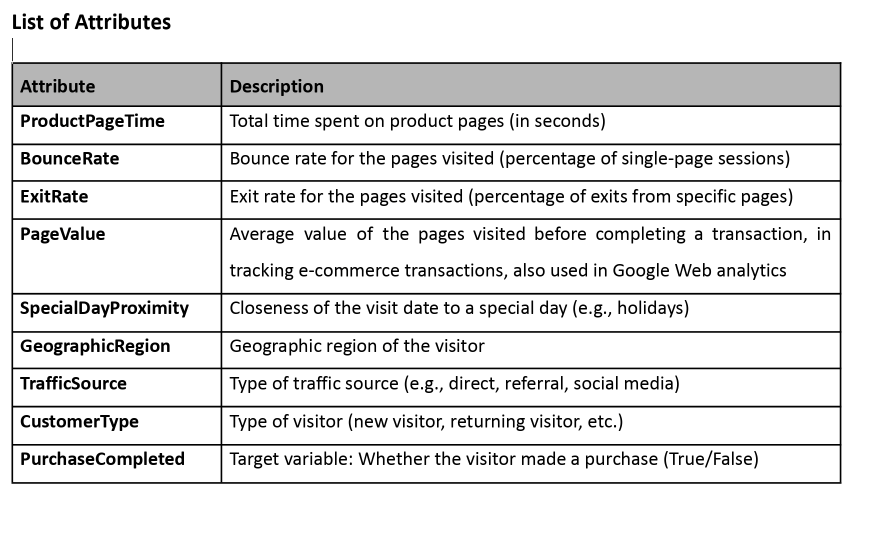

## 0.3 Installing and Importing Dependencies

In [4]:
pip install pandas numpy matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 8.9 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.2/21.2 MB 10.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 9.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 7.0 MB/s eta 0:00:00a 0:00:01
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 8.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.5/265.5 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━

In [128]:
#importing dependencies
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading Data From DB to Pandas Dataframe

In [129]:
# Connect to database
conn = sqlite3.connect('/Users/sweeken/Downloads/online_shopping.db')
cursor = conn.cursor()

# Explore which table to use
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(tables)

[('online_shopping',)]


In [130]:
# Load table directly into DataFrame
df = pd.read_sql_query("SELECT * FROM online_shopping;", conn)

In [131]:
df.info() #nulls are detected in all columns except CustomerType, GeographicRegion, BounceRate,PurchaseCompleted

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerType         12330 non-null  object 
 1   SpecialDayProximity  11714 non-null  float64
 2   ExitRate             11714 non-null  float64
 3   PageValue            11714 non-null  float64
 4   TrafficSource        11714 non-null  float64
 5   GeographicRegion     12330 non-null  int64  
 6   BounceRate           12330 non-null  float64
 7   ProductPageTime      11714 non-null  float64
 8   PurchaseCompleted    12330 non-null  int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 867.1+ KB


# 2. Primary EDA: Univariate Analysis

To investigate distributions and anomalies (nulls and erroneous inputs)

## 2.1 Distribution of CustomerType Column

In [132]:
df["CustomerType"].unique()

array(['Returning_Visitor', '', 'nan', 'Unknown', 'None', 'New_Visitor',
       'Other', 'returning_Visitor'], dtype=object)

In [133]:
df["CustomerType"].describe()

count                 12330
unique                    8
top       Returning_Visitor
freq                  10022
Name: CustomerType, dtype: object

In [134]:
df["CustomerType"].isna().sum()

np.int64(0)

CustomerType is a nominal categorical variable

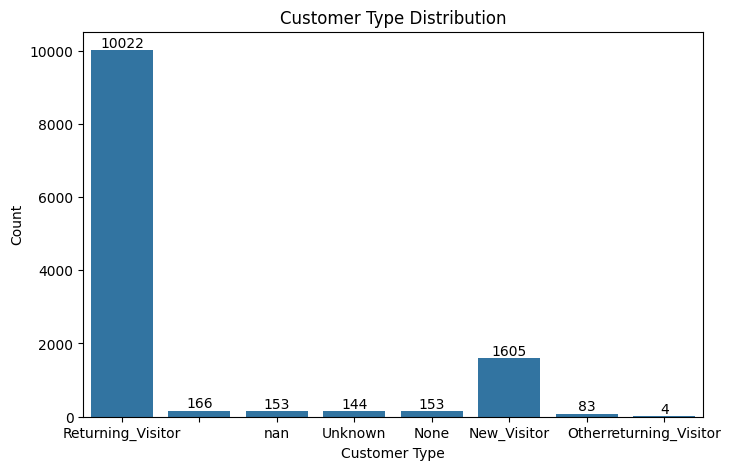

In [135]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='CustomerType', data=df)

# Get the counts
for container in ax.containers:
    ax.bar_label(container)

plt.title('Customer Type Distribution')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.show()

Returning visitors are expressed as 'Returning_Visitor' and 'returning_Visitor'. These 2 permutations need to be combined. <br>

Another valid category is 'New_Visitor', with only one permutation. <br>

Categories such as '', 'nan', 'Unknown', 'None' and 'Other' may be attributed to absence of cookies from the user. This may form a segment of e-commerce shoppers that are adverse to data collection; worthy of investigating. To do so, these categories should be recategorised into a collective category named 'Other'. <br>

## 2.2 Distribution of SpecialDayProximity Column

In [136]:
df["SpecialDayProximity"].unique()

array([0. , nan, 0.4, 0.8, 1. , 0.2, 0.6])

In [137]:
df['SpecialDayProximity'].describe()

count    11714.000000
mean         0.060833
std          0.197459
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: SpecialDayProximity, dtype: float64

In [138]:
df["SpecialDayProximity"].isna().sum() #616 NA values

np.int64(616)

SpecialDayProximity is a discrete variable

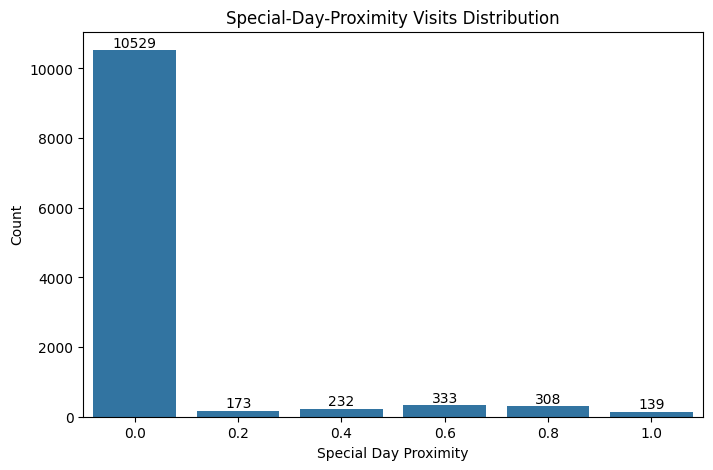

In [139]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='SpecialDayProximity', data=df)

# Get the counts
for container in ax.containers:
    ax.bar_label(container)

plt.title('Special-Day-Proximity Visits Distribution')
plt.xlabel('Special Day Proximity')
plt.ylabel('Count')
plt.show()

Generally, there is finite permutations to SpecialDayProximity column (with 0.2 intervals), hence the possibility to express it in bar charts. <br>

Most traffic comes from '0.0' proximity to special days, suggesting that traffic to the site might not be heavily impacted by proximity to special days. <br>

The column is also extremely right skewed, with a potential need for log transformation.<br>

There are also 616 NAs that may be due to absence of cookie as well.

## 2.3 Distribution of ExitRate Column

In [140]:
df["ExitRate"].unique()

array([0.2       , 0.1       , 0.14      , ..., 0.01276133, 0.01395349,
       0.02903061])

In [141]:
df["ExitRate"].describe()

count    11714.000000
mean         0.043058
std          0.048506
min          0.000000
25%          0.014286
50%          0.025286
75%          0.050000
max          0.200000
Name: ExitRate, dtype: float64

In [142]:
df["ExitRate"].isna().sum() #616 NA values

np.int64(616)

ExitRate is continuous variable

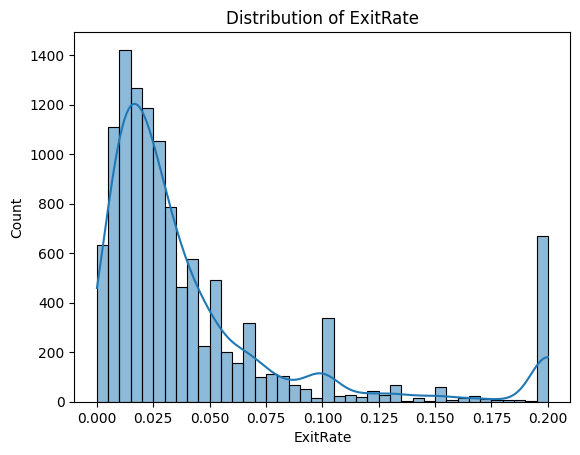

In [143]:
sns.histplot(df["ExitRate"], bins=40, kde=True)
plt.title("Distribution of ExitRate")
plt.show()

"ExitRate" is a continuous variable with finite permutations. 

Distribution is right skewed, with the median at approximately 0.017 with approximately 1,200 counts.<br>

While minimum is at 0, maximum is 0.2. to correct this moderate skewness, squareroot transformation might be used.

There are also 616 NAs that may be due to absence of cookie as well.<br>

## 2.4 Distribution of PageValue Column

In [144]:
df["PageValue"].unique()

array([ 0.        ,         nan, 54.17976426, ..., 78.81172527,
        3.68540082, 12.24171745])

In [145]:
df["PageValue"].isna().sum() #616 NA values

np.int64(616)

In [146]:
df["PageValue"].describe()

count    11714.000000
mean         5.906249
std         18.682351
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        361.763742
Name: PageValue, dtype: float64

PageValue is a continuous variable

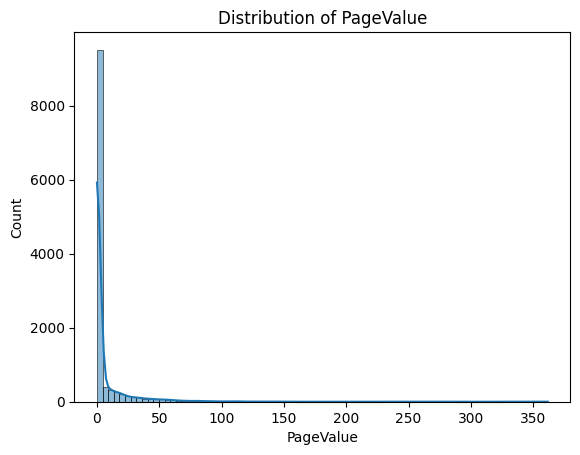

In [147]:
sns.histplot(df["PageValue"], bins=80, kde=True)
plt.title("Distribution of PageValue")
plt.show()

"PageValue" is a heavily right skewed continuous variable, where median and minimum coincides at 0, while maximum is at 361.763742.

Most pages are not attributed to value generation, or are given minimal attribution to value generation. This may suggest that attribution rules might be strict, with only the pages that contain "Add to Cart" or "Checkout" Call to Actions that are given credit.

To correct its extreme skewness, log transformation might be used.

## 2.5 Distribution of TrafficSource Column

In [148]:
df["TrafficSource"].unique()

array([ 1.,  2.,  3.,  4.,  5.,  6., nan,  7.,  8.,  9., 10., 12., 11.,
       13., 14., 15., 18., 19., 16., 17., 20.])

In [149]:
df["TrafficSource"].describe()

count    11714.000000
mean         4.059501
std          4.015758
min          1.000000
25%          2.000000
50%          2.000000
75%          4.000000
max         20.000000
Name: TrafficSource, dtype: float64

In [150]:
df["TrafficSource"].isna().sum() #616 NA values

np.int64(616)

TrafficSource is a nominal variable, with each interval representing a different traffic source. It is currently wrongly read as float.

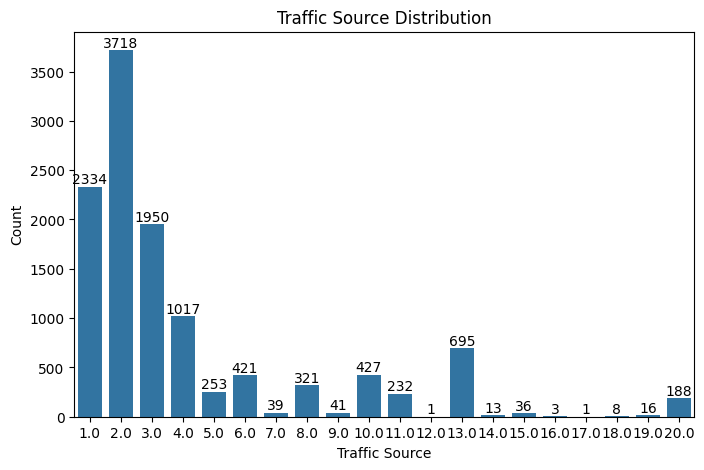

In [151]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='TrafficSource', data=df)

# Get the counts
for container in ax.containers:
    ax.bar_label(container)

plt.title('Traffic Source Distribution')
plt.xlabel('Traffic Source')
plt.ylabel('Count')
plt.show()

"TrafficSource" shows that source 2 brought in the highest amount of traffic, while source 12 and 17 brought in the least traffic. <br>

There is a need to factorise the column to change it from a float to categorical variable.

## 2.6 Distribution of GeographicRegion Column

In [152]:
df["GeographicRegion"].unique()

array([ 1, -9,  2,  3,  4, -3,  9,  5,  6,  7,  8, -4, -1, -6, -8, -2, -5,
       -7])

In [153]:
df["GeographicRegion"].describe()

count    12330.000000
mean         2.840308
std          2.757959
min         -9.000000
25%          1.000000
50%          2.000000
75%          4.000000
max          9.000000
Name: GeographicRegion, dtype: float64

In [154]:
df["GeographicRegion"].isna().sum()

np.int64(0)

GeographicRegion is a categorical variable erroneously classified as continuous.

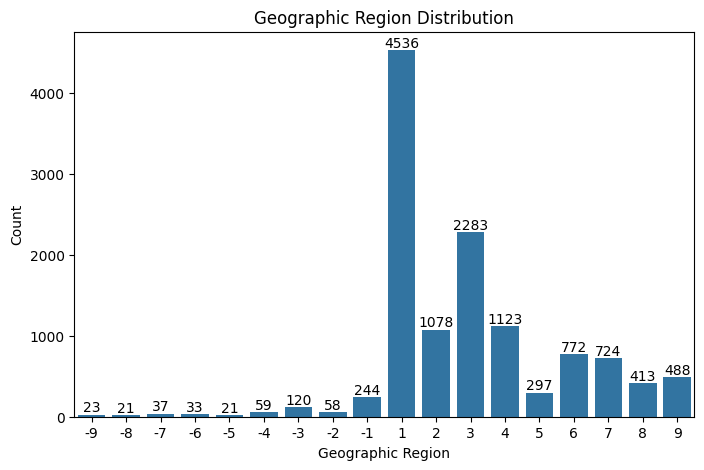

In [155]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='GeographicRegion', data=df)

# Get the counts
for container in ax.containers:
    ax.bar_label(container)

plt.title('Geographic Region Distribution')
plt.xlabel('Geographic Region')
plt.ylabel('Count')
plt.show()

Geographic Region 1 has the highest traffic. This may be attributed to consumers researching on products, and comparing against competitors - typical of behaviour from developed economies.

## 2.7 Distribution of BounceRate Column

In [156]:
df["BounceRate"].unique()

array([0.2       , 0.        , 0.05      , ..., 0.00382775, 0.00086956,
       0.01114899])

In [157]:
df["BounceRate"].isna().sum()

np.int64(0)

In [158]:
df["BounceRate"].describe()

count    12330.000000
mean         0.020024
std          0.049423
min         -0.200000
25%          0.000000
50%          0.001961
75%          0.015625
max          0.200000
Name: BounceRate, dtype: float64

BounceRate is a continuous variable

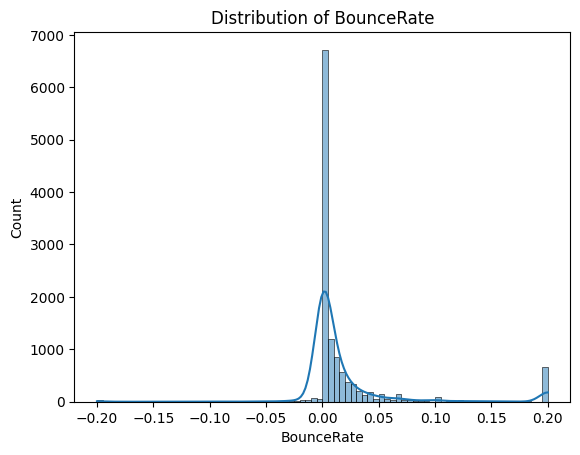

In [159]:
sns.histplot(df["BounceRate"], bins=80, kde=True)
plt.title("Distribution of BounceRate")
plt.show()

"BounceRate" has a minimum of -0.2 and a maximum of 0.2. Mathematically, this metric cannot be negative; all negative rows are invalid and should be replaced with NA. <br>

Post-removal of erroneous rows, majority of "BounceRate" is at approximately 0.003, suggesting that most traffic proceeds to visit at least one other page - the UX is successful in retaining traffic and keeping consumers engaged. <br>

"BounceRate" is also extremely right skewed, hence log transformation might be required to normalise this feature.

## 2.8 Distribution of ProductPageTime Column

In [160]:
df["ProductPageTime"].unique()

array([  0.        ,  64.        ,   2.66666667, ..., 465.75      ,
       184.25      , 346.        ])

In [161]:
df["ProductPageTime"].isna().sum() #616 NA values  

np.int64(616)

In [162]:
df["ProductPageTime"].describe()

count    11714.000000
mean      1198.698632
std       1928.871645
min        -52.500000
25%        184.270833
50%        602.958333
75%       1465.955181
max      63973.522230
Name: ProductPageTime, dtype: float64

ProductPageTime is a continuous variable

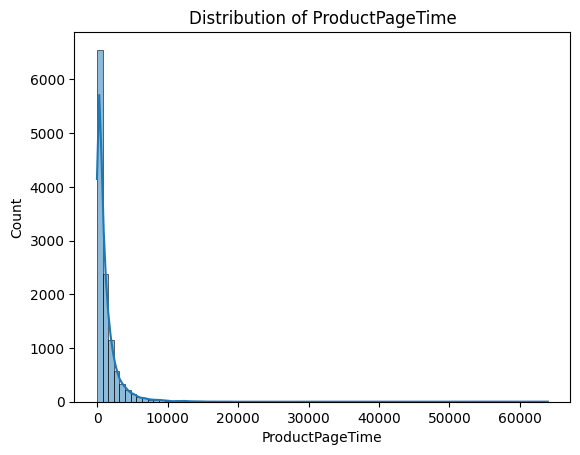

In [163]:
sns.histplot(df["ProductPageTime"], bins=80, kde=True)
plt.title("Distribution of ProductPageTime")
plt.show()

"ProductPageTime" has a minimum of -52.5 - all negative rows are logically unsound and need to be replaced with NA. <br>

Post removal, this feature is still heavily right skewed, with majority of entries at approximately 50 seconds, and the maximum at 63973,522230 seconds. Log transformation may be required to address skewness.<br>

A possible reason for right skewness might be accounted for by leaving the page open when there is still inactivity (which counters the purpose of this metric). Outliers may be required to be removed.<br>

The scale of this feature is significantly larger than the others; scaling might be required.

## 2.9 Distribution of PurchaseCompleted Column (Target)

In [164]:
df["PurchaseCompleted"].unique()

array([0, 1])

In [165]:
df["PurchaseCompleted"].isna().sum()

np.int64(0)

In [166]:
df["PurchaseCompleted"].describe()

count    12330.000000
mean         0.154745
std          0.361676
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: PurchaseCompleted, dtype: float64

PurchaseCompleted is a target variable that is supposedly a boolean, but is read as Int64.

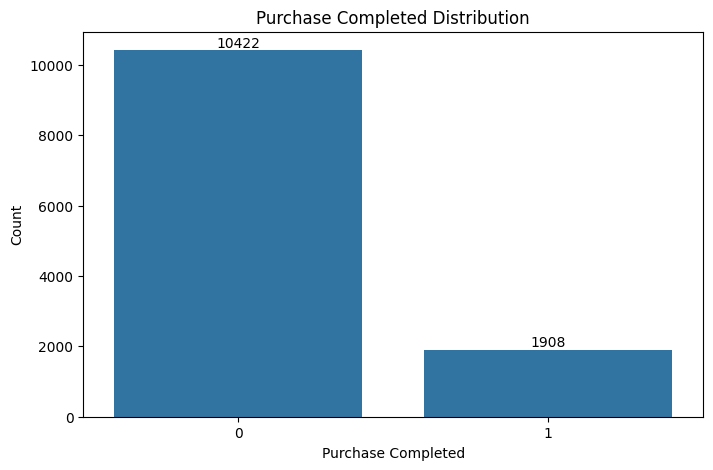

In [167]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='PurchaseCompleted', data=df)

# Get the counts
for container in ax.containers:
    ax.bar_label(container)

plt.title('Purchase Completed Distribution')
plt.xlabel('Purchase Completed')
plt.ylabel('Count')
plt.show()

There is a significant class imbalance, where most of traffic does not complete purchases. Hence there is a need to rebalance this target variable. <br>

# 3. Data Cleaning

## 3.1 Handling Misclassification in CustomerType

Falling outside of "Returning_Visitor" or "New_Visitor" might suggest web visitors' browser cookies cannot be captured or persisted due to rejection of cookie consent, browsing in private mode, using ad-blocking software or clearing cookies. This points to possible privacy consciousness of these users.<br>

This hidden segment might be helpful in establishing relationships in our study, hence reclassified as "Other"

In [170]:
df["CustomerType"] = (
    df["CustomerType"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "returning_visitor": "Returning_Visitor",
        "new_visitor": "New_Visitor",
        "": "Other" ,
        "nan": "Other",
        "unknown": "Other",
        "none": "Other",
        "other": "Other"
    })
)

#Verify if reclassification is successful
df["CustomerType"].unique()

array(['Returning_Visitor', 'Other', 'New_Visitor'], dtype=object)

## 3.2 Handling of Absurd Values

This section changes absurd values in BounceRate and ProductPageTime that are negative to NA

### 3.2.1 Negative Values in BounceRate

In [181]:
df.loc[df["BounceRate"] < 0, "BounceRate"] = None

#Verify if fix is performed
(df["BounceRate"] < 0).sum()

np.int64(0)

In [184]:
df["BounceRate"].isna().sum()

np.int64(348)

BounceRate now has 348 NA values

### 3.2.2 Negative Values in ProductPageTime

In [183]:
df.loc[df["ProductPageTime"] < 0, "ProductPageTime"] = None

#Verify if fix is performed
(df["ProductPageTime"] < 0).sum()

np.int64(0)

In [186]:
df["ProductPageTime"].isna().sum()

np.int64(620)

ProductPageTime now has 620 NA values

## 3.3 Handling NAs

### 3.3.1 Do all NAs come from the same rows?

In [189]:
df.isna().any(axis=1).sum()

np.int64(3036)

In [190]:
df.isna().sum() #this depicts the number of NAs in each feature

CustomerType             0
SpecialDayProximity    616
ExitRate               616
PageValue              616
TrafficSource          616
GeographicRegion         0
BounceRate             348
ProductPageTime        620
PurchaseCompleted        0
dtype: int64

In [191]:
df.isna().sum(axis=1).value_counts() #this depicts the number of rows with 0-3 counts of NA within itself

0    9294
1    2674
2     329
3      32
4       1
Name: count, dtype: int64

NAs are not found in the same rows - missingness is spread across the dataset. Hence, incomplete rows should not be dropped since they form approximately 25% of the data. Imputation should be adopted.

### 3.2.2 Imputation for Continuous/Discrete Variables

For features with moderate to high skewness, median imputation will be an appropriate manner of imputation to represent the distribution of the respective feature. these features are:
- SpecialDayProximity
- ExitRate
- PageValue
- ProductPageTime
- BounceRate

Another manner considered is potentially Predictive Imputation that can use relationships between features to suggest a value. <br>

This will be tested during pipeline building.

## 3.4 Rectification of Data Types

Features are changed to their correct data types as seen below:<br>
Categorical
- CustomerType
- TrafficSource
- GeographicRegion

Boolean
- PurchaseCompleted

In [192]:
cat_cols = ["CustomerType", "TrafficSource", "GeographicRegion"]
df[cat_cols] = df[cat_cols].astype("category")

df["PurchaseCompleted"] = df["PurchaseCompleted"].astype("bool")

# 4. Bivariate Analysis

## 4.1 Correlation Plot for Numerical Columns

Note: The target variable is temporarily changed to numerical to aid in correlation identification

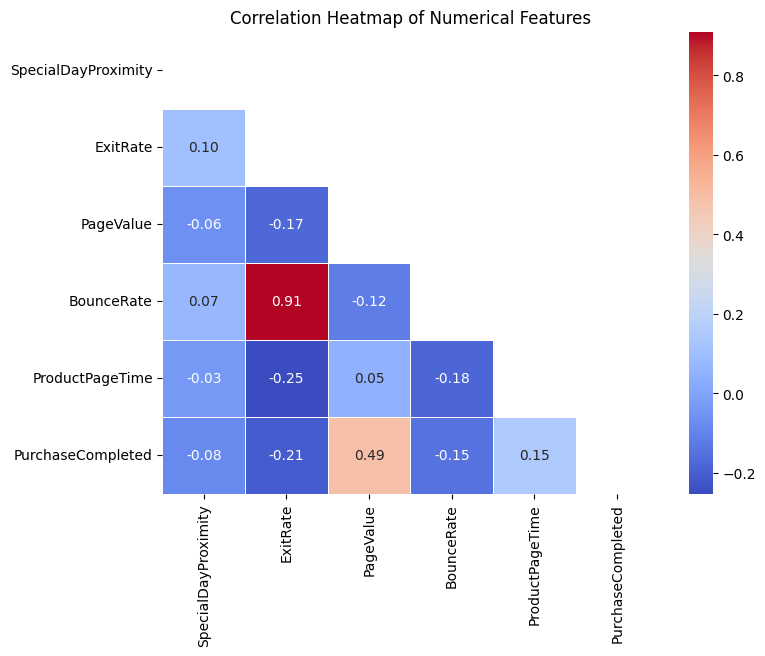

In [ ]:
df_corr = df.copy()

df_corr["PurchaseCompleted"] = df_corr["PurchaseCompleted"].astype(int)

num_df = df_corr.select_dtypes(include=["number"]) # Select only numerical columns

corr_matrix = num_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

1. BounceRate and ExitRate has extremely high correlation. It can be inferred that these 2 metrics measure very similar engagement behaviour (BounceRate refers to users leaving immediately, while ExitRate refers to users leaving after browsing). Using both features may become redundant; when linear models are used in modelling, multicollinearity may become a problem. <br>
2. PageValue is the strongest predictor of purchase; users browsing high-value pages are more likely to buy. In view of the marketing funnel, this variable might represent progression along the purchase funnel and is essential in measuring completion of purchase. <br>
3. Negative correlations between target variable and both ExitRate and BounceRate suggests that pages that lack engagement may cause less likely purchase behaviour.

## 4.2 Numerical Predictors against Target

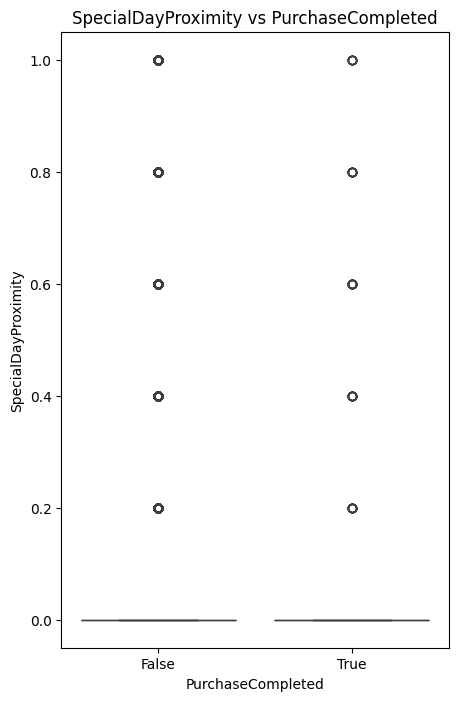

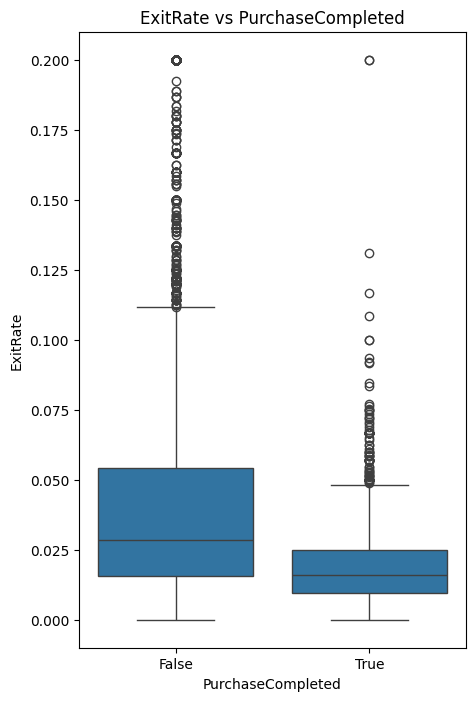

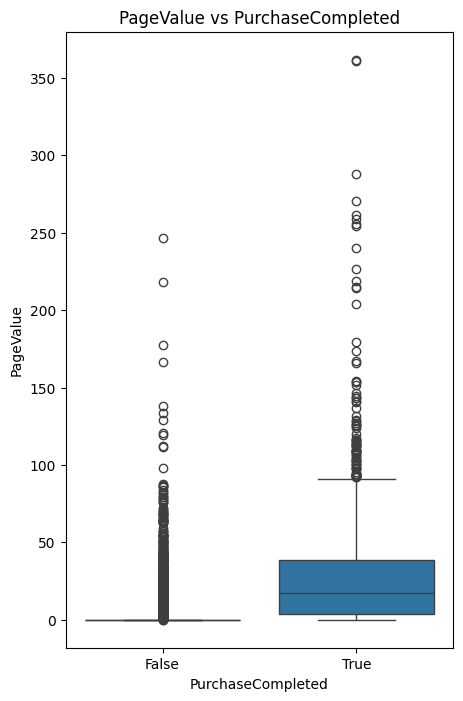

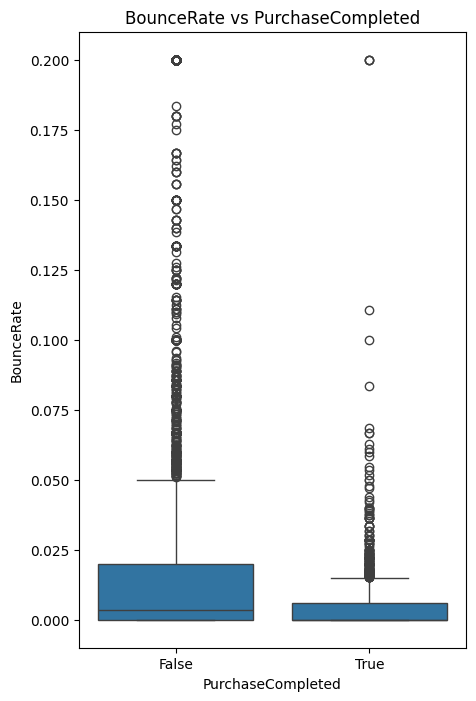

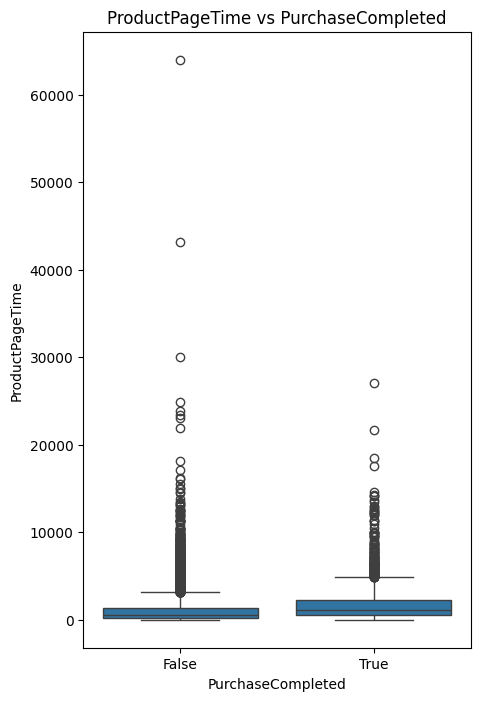

In [196]:
num_cols = [
    "SpecialDayProximity",
    "ExitRate",
    "PageValue",
    "BounceRate",
    "ProductPageTime"
]

for col in num_cols:
    plt.figure(figsize=(5,8))
    sns.boxplot(x="PurchaseCompleted", y=col, data=df)
    plt.title(f"{col} vs PurchaseCompleted")
    plt.show()

1. SpecialDayProximity can be inferred to have minimal impact on Purchase Outcome with highly similar distributions.
2. Purchases have lower ExitRates as compared to non-purchases as seen through lower median ExitRate and smaller spread of values in purchasers. This may suggest that purchasers were stringent on evaluating the purchase to ensure it fits what they desire.
3. Purchasing sessions can be concluded to have significantly higher PageValue with wider distribution, while non-purchasing sessions mostly have near zero PageValue. It shows that high-value pages are essential in driving conversion, yet the high variation in values of purchasers suggest that users browse multiple high-value pages before buying (this might suggest that some purchasers need more convincing than others, and the spread is considerably large)
4. Purchasing sessions tend to have lower bounce rates, with slightly lower median and overall tighter distribution. This suggests that initial targeting and awareness raising is essential in driving purchases amidst information overload in today's world.
5. Purchasing sessions tend to spend more time on product pages, with higher median for successful purchases. This implies that tend to taske their time in investigating products, and this scrutiny of purchasers may suggest careful consumption.

## 4.3 Categorical Predictors against Target

/var/folders/dy/fq_f26557ld286fq56q3zmzh0000gn/T/ipykernel_77591/633217429.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion = df.groupby(col)["PurchaseCompleted"].mean()


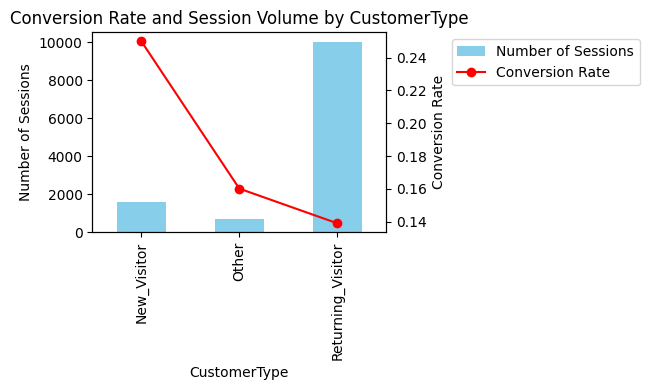

/var/folders/dy/fq_f26557ld286fq56q3zmzh0000gn/T/ipykernel_77591/633217429.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion = df.groupby(col)["PurchaseCompleted"].mean()


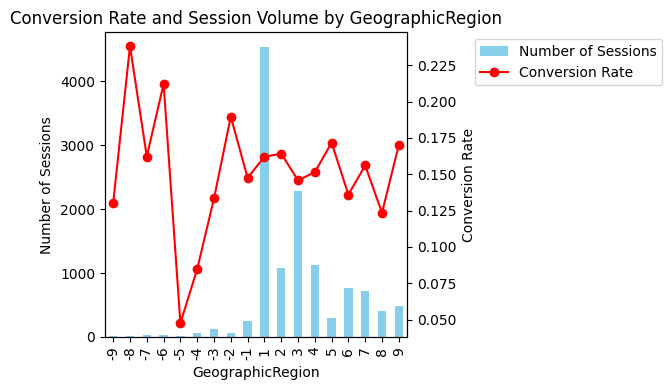

/var/folders/dy/fq_f26557ld286fq56q3zmzh0000gn/T/ipykernel_77591/633217429.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion = df.groupby(col)["PurchaseCompleted"].mean()


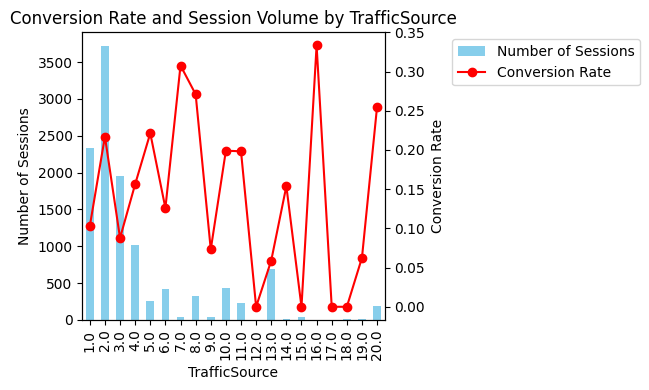

In [249]:
cat_cols = ["CustomerType", "GeographicRegion", "TrafficSource"]

for col in cat_cols:

    fig, ax1 = plt.subplots(figsize=(7,4))

    # Count bars
    counts = df[col].value_counts().sort_index()
    bars = counts.plot(kind="bar", ax=ax1, color="skyblue", label="Number of Sessions")
    
    ax1.set_ylabel("Number of Sessions")
    ax1.set_xlabel(col)

    # Conversion rate line
    conversion = df.groupby(col)["PurchaseCompleted"].mean()

    ax2 = ax1.twinx()
    line = conversion.loc[counts.index].plot(
        ax=ax2, marker="o", color="red", label="Conversion Rate"
    )

    ax2.set_ylabel("Conversion Rate")

    # Combine legends
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="upper left",
        bbox_to_anchor=(1.2, 1)
    )

    plt.title(f"Conversion Rate and Session Volume by {col}")
    plt.tight_layout()
    plt.show()

1. Highest traffic CustomerType has lowest conversion rate, suggesting that there is lack of returning purchases
2. Similarly, in GeographicRegions with high traffic, there is only moderately high conversion rate.
3. Similarly in TrafficSOurces with high traffic, there is only moderately high conversion rate.

This suggests that targeting new visitors from geographic regions and traffic sources that has high conversion rates will give higher chances of successful purchases. 

## 4.4 Predictor against Predictor 

This serves to spot multi-collinearity, explore hidden relationships and potential feature engineering opportunities.

### 4.4.1 Hypothesis 1: BounceRate and ExitRate measures similar behaviour

<Axes: xlabel='BounceRate', ylabel='ExitRate'>

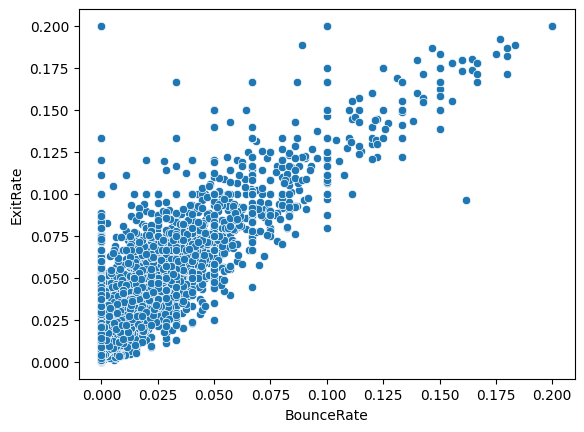

In [250]:
sns.scatterplot(data=df, x="BounceRate", y="ExitRate")

Scatterplot suggests high correlation, similar to that from the correlation plot. While BounceRate is a subset of ExitRate, both suggests different insights and are both necessary. Models that are susceptible to multicollinearity cannot be used.

### 4.4.2 Hypothesis 2: Users who spend more time on product pages have lower exit rates.

<Axes: xlabel='ProductPageTime', ylabel='ExitRate'>

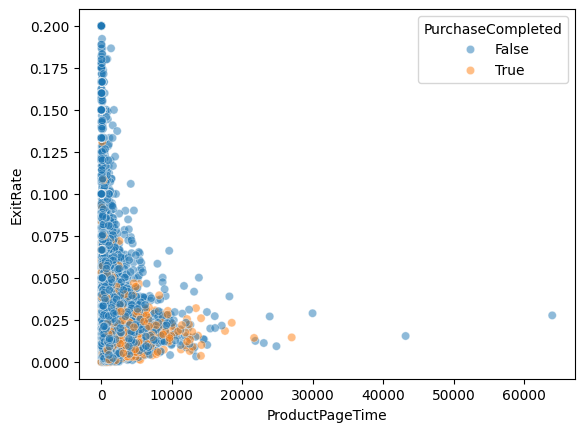

In [256]:
sns.scatterplot(
    data=df,
    x="ProductPageTime",
    y="ExitRate",
    hue="PurchaseCompleted",
    alpha=0.5
)

The scatter plot reveals that sessions resulting in purchases tend to exhibit longer product browsing time and lower exit rates. This suggests that higher engagement with product pages is associated with stronger product satisfaction, while sessions with minimal browsing activity and higher exit rates rarely lead to transactions.

### 4.4.3 Hypothesis 3: Specific Geographic Regions or Traffic Sources are deterred from completing the full funnel despite deep exploration.

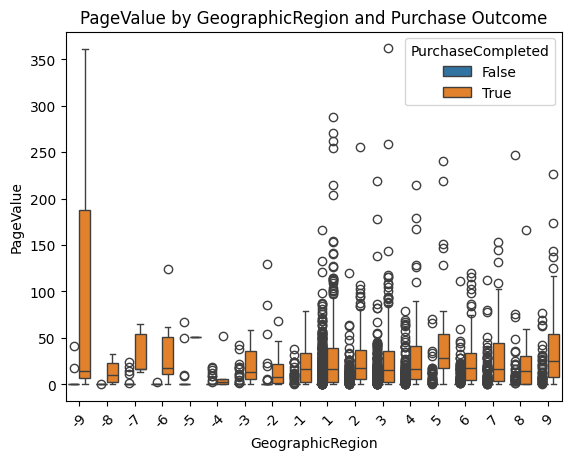

In [271]:
sns.boxplot(
    data=df,
    x="GeographicRegion",
    y="PageValue",
    hue="PurchaseCompleted"
)

plt.xticks(rotation=45)
plt.title("PageValue by GeographicRegion and Purchase Outcome")
plt.show()

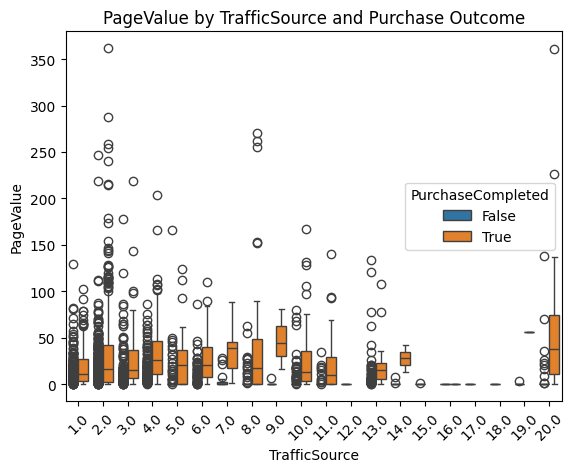

In [272]:
sns.boxplot(
    data=df,
    x="TrafficSource",
    y="PageValue",
    hue="PurchaseCompleted"
)

plt.xticks(rotation=45)
plt.title("PageValue by TrafficSource and Purchase Outcome")
plt.show()

We can see that:
- While successful purchases has to naturally navigate through high value pages, 
- Geographic regions -1 to 9 and traffic sources 1 to 13 exhibited outliers that also navigated through high value pages.
- This suggests that there were intention to purchase but may have been stopped by some reasons such as waiting for promotions, high shipping fees etc
- This is especially significant for TrafficSources that have higher trust and interest, and for GeographicRegions that may be more price sensitive

To further value add, we can draw boundaries to demarcate progression through the purchase funnel:
1. Awareness: PageValue = 0
2. Consideration: PageValue > 0
3. Purchase: PurchaseCompleted == True


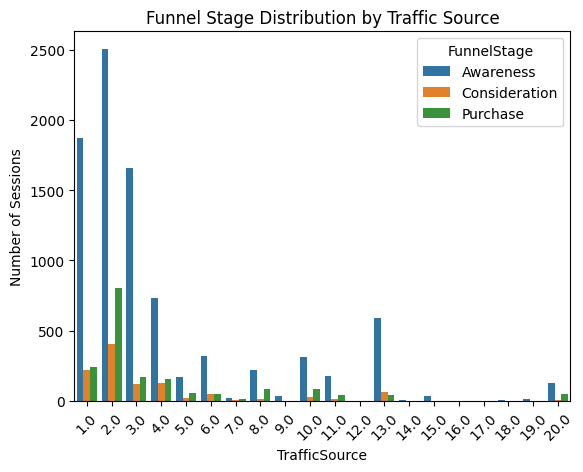

In [278]:
df["FunnelStage"] = np.where(
    df["PurchaseCompleted"] == True,
    "Purchase",
    np.where(df["PageValue"] > 0, "Consideration", "Awareness")
)

sns.countplot(
    data=df,
    x="TrafficSource",
    hue="FunnelStage"
)

plt.xticks(rotation=45)
plt.title("Funnel Stage Distribution by Traffic Source")
plt.ylabel("Number of Sessions")
plt.show()

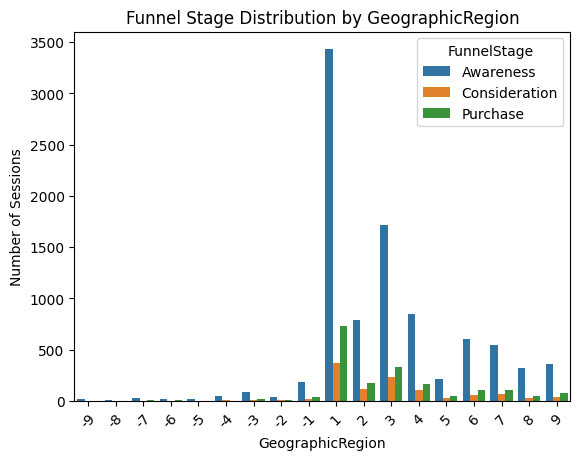

In [276]:
df["FunnelStage"] = np.where(
    df["PurchaseCompleted"] == True,
    "Purchase",
    np.where(df["PageValue"] > 0, "Consideration", "Awareness")
)

sns.countplot(
    data=df,
    x="GeographicRegion",
    hue="FunnelStage"
)

plt.xticks(rotation=45)
plt.title("Funnel Stage Distribution by GeographicRegion")
plt.ylabel("Number of Sessions")
plt.show()

The hypothesis is especially true for TrafficSource, with sources 1, 2, 3, and 4 having a sizeable amount of traffic in the consideration phase as compared to purchase; this signifies that instilling trust might be a issue inhibiting full conversion.

The hypothesis might be weakly true for GeographicRegion, with a smaller proportion of traffic stuck in the consideration phase as compared to purchase; this signifies that the products might be have low price elasticity.